In [2]:
import json
import matplotlib

In [3]:
def read_jsonl(path):
    data = []
    with open(path, "r") as f:
        for line in f:
            doc = json.loads(line)
            data.append(doc["similarity"])

    return data

sims = read_jsonl("../results/benchmarks/originals/descriptors_originals.jsonl")

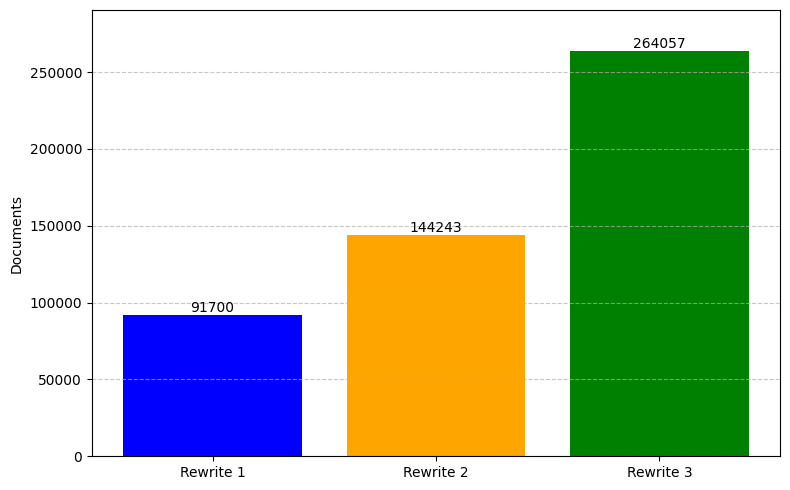

[91700, 144243, 264057]

In [5]:
import matplotlib.pyplot as plt

def plot_max_indices(data):
    # Count how many times each index (0, 1, 2) has the max value
    counts = [0, 0, 0]
    for sublist in data:
        max_val = max(sublist)
        max_indices = [i for i, val in enumerate(sublist) if val == max_val]
        # If there's a tie, we'll count the first occurrence
        counts[max_indices[0]] += 1

    # Plotting
    plt.figure(figsize=(8, 5))
    bars = plt.bar(["Rewrite 1", "Rewrite 2", "Rewrite 3"], counts,
                   color=["blue", "orange", "green"])

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom')

    plt.ylabel("Documents")
    plt.ylim(0, max(counts) * 1.1)  # Add some padding
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return counts

plot_max_indices(sims)

In [6]:
difs = []
for sim in sims:
    one_two = sim[1]-sim[0]
    two_three = sim[2]-sim[1]
    difs.append((one_two, two_three))

average_difs_one_two = sum([sim[0] for sim in difs])/len(difs)
average_difs_two_three = sum([sim[1] for sim in difs])/len(difs)

In [7]:
average_difs_one_two

0.029204977000000385

In [8]:
average_difs_two_three

0.009949780200000199

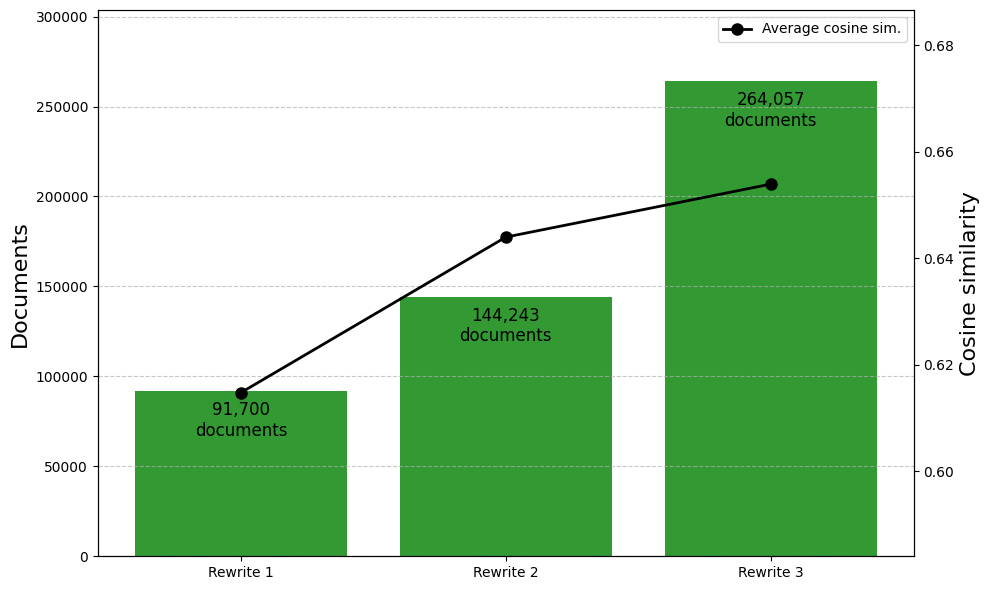

([91700, 144243, 264057],
 [0.6147697449999912, 0.643974722000008, 0.6539245022000291])

In [16]:
import matplotlib.pyplot as plt

def plot_max_indices_with_position_averages(data):
    # Count how many times each index (0, 1, 2) has the max value
    counts = [0, 0, 0]
    position_sums = [0, 0, 0]

    for sublist in data:
        max_val = max(sublist)
        max_indices = [i for i, val in enumerate(sublist) if val == max_val]
        counts[max_indices[0]] += 1

        # Sum values for each position
        for i, val in enumerate(sublist):
            position_sums[i] += val

    # Calculate averages for each position
    position_averages = [s/len(data) for s in position_sums]

    # Create figure
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar plot for max index counts
    bars = ax1.bar(["Rewrite 1", "Rewrite 2", "Rewrite 3"], counts,
                  color=["green", "green", "green"], alpha=0.8)
    ax1.set_ylabel("Documents", color="black", fontsize=16)
    ax1.set_ylim(0, max(counts) * 1.15)

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        offset = -27000
        ax1.text(bar.get_x() + bar.get_width()/2., height+offset,
                f'{int(height):,}\ndocuments',
                ha='center', va='bottom', fontsize=12)

    # Line plot for position averages on secondary axis
    ax2 = ax1.twinx()
    line, = ax2.plot(range(3), position_averages, 'o-', color="black",
                    linewidth=2, markersize=8, label="Average cosine sim.")
    ax2.set_ylabel("Cosine similarity", fontsize=16)
    ax2.tick_params(axis='y')
    ax2.set_ylim(min(position_averages)*0.95, max(position_averages)*1.05)

    # Customize the plot
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

    # Add grid
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("../figures/rewrite_score_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

    return counts, position_averages


plot_max_indices_with_position_averages(sims)